In [ ]:
# ============================================================
# CELL 1 — INSTALL (Optional)
# ============================================================

# Uncomment if dependencies are missing
# !pip install sentence-transformers faiss-cpu rank-bm25

In [ ]:
# ============================================================
# CELL 2 — IMPORTS
# ============================================================

import faiss
import pickle
import json
import time
import os
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, CrossEncoder

# FOR LOCAL
import torch
torch.set_num_threads(4)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

print("Libraries loaded successfully.")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Libraries loaded successfully.
Timestamp: 2026-06-04 18:09:26


In [ ]:
# ============================================================
# CELL 3 — CONFIGURATION
# ============================================================

CONFIG = {
    # Paths
    "faiss_index_path": "../parquet_exports/ticket_similarity.index",
    "embedding_metadata_path": "../parquet_exports/embedding_metadata.parquet",
    "bm25_corpus_path": "../parquet_exports/bm25_corpus.pkl",
    "export_path": "../evaluation/reranking_results.csv",
    "benchmark_export_path": "../evaluation/benchmarks/reranking_latency.csv",

    # Models
    #"embedding_model_name": "sentence-transformers/all-MiniLM-L6-v2",
    #"cross_encoder_model_name": "cross-encoder/ms-marco-MiniLM-L-6-v2",
    "embedding_model_name": "BAAI/bge-small-en-v1.5",
    "cross_encoder_model_name": "cross-encoder/ms-marco-MiniLM-L-12-v2",

    # Retrieval params
    #"top_k_faiss": 20,
    "top_k_faiss": 20,
    #"top_k_bm25": 20,
    "top_k_bm25": 20,
    "rrf_k": 60,
    #"hybrid_top_k": 10,
    "hybrid_top_k": 20,
    

    # Reranking params
    "rerank_top_k": 10,
    #"cross_encoder_batch_size": 32,
    "cross_encoder_batch_size": 16,

    #"max_context_tokens": 2048,
    "max_context_tokens": 512,
}

print("=" * 60)
print("CONFIGURATION")
print("=" * 60)
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

CONFIGURATION
  faiss_index_path: ../parquet_exports/ticket_similarity.index
  embedding_metadata_path: ../parquet_exports/embedding_metadata.parquet
  bm25_corpus_path: ../parquet_exports/bm25_corpus.pkl
  export_path: ../evaluation/reranking_results.csv
  benchmark_export_path: ../evaluation/benchmarks/reranking_latency.csv
  embedding_model_name: BAAI/bge-small-en-v1.5
  cross_encoder_model_name: cross-encoder/ms-marco-MiniLM-L-12-v2
  top_k_faiss: 20
  top_k_bm25: 20
  rrf_k: 60
  hybrid_top_k: 20
  rerank_top_k: 5
  cross_encoder_batch_size: 16
  max_context_tokens: 512


In [ ]:
# ============================================================
# CELL 4 — LOGGING HELPERS
# ============================================================

def log(level, component, message):
    ts = datetime.now().strftime("%H:%M:%S")
    print(f"[{ts}] [{level}] [{component}] {message}")


def log_step(step_name):
    print(f"\n{'=' * 60}")
    print(f"  {step_name}")
    print(f"{'=' * 60}")


print("Logging helpers ready.")

Logging helpers ready.


In [ ]:
# ============================================================
# CELL 5 — LOAD FAISS INDEX
# ============================================================

index = None
try:
    log_step("LOADING FAISS INDEX")
    t0 = time.time()
    index = faiss.read_index(CONFIG["faiss_index_path"])
    elapsed = time.time() - t0
    log("OK", "FAISS", f"Loaded {index.ntotal:,} vectors in {elapsed:.2f}s")
    assert index.ntotal > 0, "FAISS index is empty"
    log("OK", "FAISS", f"Dimension: {index.d}")
except FileNotFoundError:
    log("ERROR", "FAISS", f"Index not found at {CONFIG['faiss_index_path']}")
    log("ERROR", "FAISS", "Run notebook 06_embedding_pipeline.ipynb first")
    raise
except Exception as e:
    log("ERROR", "FAISS", f"Failed to load: {e}")
    raise


  LOADING FAISS INDEX
[18:09:26] [OK] [FAISS] Loaded 228,561 vectors in 0.41s
[18:09:26] [OK] [FAISS] Dimension: 384


In [ ]:
# ============================================================
# CELL 6 — LOAD METADATA
# ============================================================

metadata_df = None
required_cols = ["chunk_id", "chunk_text", "document_id", "ticket_pk"]

try:
    log_step("LOADING METADATA")
    t0 = time.time()
    metadata_df = pd.read_parquet(CONFIG["embedding_metadata_path"])
    elapsed = time.time() - t0
    log("OK", "METADATA", f"Loaded {len(metadata_df):,} rows, {metadata_df.shape[1]} cols in {elapsed:.2f}s")

    missing_cols = [c for c in required_cols if c not in metadata_df.columns]
    if missing_cols:
        log("WARN", "METADATA", f"Missing columns: {missing_cols}")
    else:
        log("OK", "METADATA", f"Required columns present: {required_cols}")
except FileNotFoundError:
    log("ERROR", "METADATA", f"File not found at {CONFIG['embedding_metadata_path']}")
    raise
except Exception as e:
    log("ERROR", "METADATA", f"Failed to load: {e}")
    raise


  LOADING METADATA
[18:09:27] [OK] [METADATA] Loaded 228,561 rows, 9 cols in 0.23s
[18:09:27] [OK] [METADATA] Required columns present: ['chunk_id', 'chunk_text', 'document_id', 'ticket_pk']


In [ ]:
# ============================================================
# CELL 7 — LOAD BM25 CORPUS & BUILD INDEX
# ============================================================

bm25 = None
bm25_tokens = None

try:
    log_step("LOADING BM25 CORPUS")
    t0 = time.time()
    bm25_tokens = pd.read_pickle(CONFIG["bm25_corpus_path"])
    log("OK", "BM25", f"Loaded {len(bm25_tokens):,} documents in {time.time()-t0:.2f}s")

    assert len(bm25_tokens) > 0, "BM25 corpus is empty"

    t0 = time.time()
    bm25 = BM25Okapi(bm25_tokens.tolist())
    log("OK", "BM25", f"Index built in {time.time()-t0:.2f}s")
except FileNotFoundError:
    log("ERROR", "BM25", f"File not found at {CONFIG['bm25_corpus_path']}")
    raise
except Exception as e:
    log("ERROR", "BM25", f"Failed to load: {e}")
    raise


  LOADING BM25 CORPUS
[18:09:28] [OK] [BM25] Loaded 228,561 documents in 1.31s
[18:09:33] [OK] [BM25] Index built in 4.83s


In [ ]:
# ============================================================
# CELL 8 — LOAD EMBEDDING MODEL
# ============================================================

embedding_model = None

try:
    log_step("LOADING EMBEDDING MODEL")
    t0 = time.time()
    embedding_model = SentenceTransformer(CONFIG["embedding_model_name"])
    elapsed = time.time() - t0
    log("OK", "EMBEDDING", f"Model '{CONFIG['embedding_model_name']}' loaded in {elapsed:.2f}s")
    log("OK", "EMBEDDING", f"Device: {embedding_model.device}")
except Exception as e:
    log("ERROR", "EMBEDDING", f"Failed to load model: {e}")
    raise


  LOADING EMBEDDING MODEL
[18:09:36] [OK] [EMBEDDING] Model 'BAAI/bge-small-en-v1.5' loaded in 2.77s
[18:09:36] [OK] [EMBEDDING] Device: cpu


In [ ]:
# ============================================================
# CELL 9 — RETRIEVAL FUNCTIONS
# ============================================================

def faiss_search(query: str, top_k: int = 10) -> pd.DataFrame:
    try:
        q_emb = embedding_model.encode(
            [query], convert_to_numpy=True, normalize_embeddings=True
        ).astype("float32")
        scores, indices = index.search(q_emb, top_k)
        results = []
        for rank, (score, idx) in enumerate(zip(scores[0], indices[0])):
            row = metadata_df.iloc[idx]
            results.append({
                "retriever": "faiss",
                "rank": rank + 1,
                "score": float(score),
                "chunk_id": row["chunk_id"],
                "text": row["chunk_text"]
            })
        return pd.DataFrame(results)
    except Exception as e:
        log("ERROR", "FAISS_SEARCH", f"Query failed: {e}")
        return pd.DataFrame(columns=["retriever", "rank", "score", "chunk_id", "text"])


def bm25_search(query: str, top_k: int = 10) -> pd.DataFrame:
    try:
        tok_q = query.lower().split()
        scores = bm25.get_scores(tok_q)
        top_indices = np.argsort(scores)[::-1][:top_k]
        results = []
        for rank, idx in enumerate(top_indices):
            row = metadata_df.iloc[idx]
            results.append({
                "retriever": "bm25",
                "rank": rank + 1,
                "score": float(scores[idx]),
                "chunk_id": row["chunk_id"],
                "text": row["chunk_text"]
            })
        return pd.DataFrame(results)
    except Exception as e:
        log("ERROR", "BM25_SEARCH", f"Query failed: {e}")
        return pd.DataFrame(columns=["retriever", "rank", "score", "chunk_id", "text"])


def reciprocal_rank_fusion(result_frames: list, k: int = 60) -> pd.DataFrame:
    rrf_scores = {}
    text_lookup = {}
    for df in result_frames:
        for _, row in df.iterrows():
            cid = row["chunk_id"]
            rrf_scores[cid] = rrf_scores.get(cid, 0) + 1 / (k + row["rank"])
            text_lookup[cid] = row["text"]
    fused = pd.DataFrame([
        {"chunk_id": cid, "rrf_score": sc, "text": text_lookup[cid]}
        for cid, sc in rrf_scores.items()
    ])
    return fused.sort_values("rrf_score", ascending=False).reset_index(drop=True)


def hybrid_search(query: str, top_k: int = 10) -> pd.DataFrame:
    bm25_df = bm25_search(query, top_k=top_k)
    faiss_df = faiss_search(query, top_k=top_k)
    if bm25_df.empty and faiss_df.empty:
        log("WARN", "HYBRID", f"Both retrievers returned empty for: {query}")
        return pd.DataFrame(columns=["chunk_id", "rrf_score", "text"])
    return reciprocal_rank_fusion([bm25_df, faiss_df], k=CONFIG["rrf_k"]).head(top_k)


print("Retrieval functions defined.")

Retrieval functions defined.


In [ ]:
# ============================================================
# CELL 10 — LOAD CROSS-ENCODER
# ============================================================

cross_encoder = None

try:
    log_step("LOADING CROSS-ENCODER")
    t0 = time.time()
    cross_encoder = CrossEncoder(
        CONFIG["cross_encoder_model_name"],
        max_length=CONFIG["max_context_tokens"],
    )
    elapsed = time.time() - t0
    log("OK", "CROSSENCODER", f"Model '{CONFIG['cross_encoder_model_name']}' loaded in {elapsed:.2f}s")
except Exception as e:
    log("ERROR", "CROSSENCODER", f"Failed to load: {e}")
    log("ERROR", "CROSSENCODER", "Falling back: reranking will be skipped")
    cross_encoder = None


  LOADING CROSS-ENCODER
[18:09:38] [OK] [CROSSENCODER] Model 'cross-encoder/ms-marco-MiniLM-L-12-v2' loaded in 1.83s


In [ ]:
# ============================================================
# CELL 11 — RERANKING FUNCTIONS
# ============================================================

def rerank_results(
    query: str,
    hybrid_df: pd.DataFrame,
    top_k: int = 5,
) -> pd.DataFrame:
    if cross_encoder is None:
        log("WARN", "RERANK", "No CrossEncoder available, returning hybrid results")
        hybrid_df["rerank_score"] = hybrid_df["rrf_score"]
        return hybrid_df.head(top_k)

    if hybrid_df.empty:
        log("WARN", "RERANK", "Empty input, returning empty")
        return hybrid_df

    try:
        pairs = [[query, text] for text in hybrid_df["text"].tolist()]

        rerank_scores = cross_encoder.predict(
            pairs,
            batch_size=CONFIG["cross_encoder_batch_size"],
            show_progress_bar=False,
        )

        rerank_scores = rerank_scores.tolist() if hasattr(rerank_scores, "tolist") else list(rerank_scores)

        result_df = hybrid_df.copy()
        result_df["rerank_score"] = rerank_scores
        result_df = result_df.sort_values("rerank_score", ascending=False).reset_index(drop=True)
        result_df["rerank_rank"] = range(1, len(result_df) + 1)

        log("OK", "RERANK", f"Reranked {len(result_df)} items, top score: {result_df['rerank_score'].iloc[0]:.4f}")

        return result_df.head(top_k)
    except Exception as e:
        log("ERROR", "RERANK", f"Reranking failed: {e}")
        hybrid_df["rerank_score"] = hybrid_df["rrf_score"]
        return hybrid_df.head(top_k)


def retrieve_and_rerank(
    query: str,
    hybrid_top_k: int = 10,
    rerank_top_k: int = 5,
) -> pd.DataFrame:
    t_start = time.time()

    t0 = time.time()
    hybrid_df = hybrid_search(query, top_k=hybrid_top_k)
    retrieval_latency = time.time() - t0

    if hybrid_df.empty:
        log("WARN", "PIPELINE", f"No results for: {query}")
        return pd.DataFrame()

    t0 = time.time()
    reranked_df = rerank_results(query, hybrid_df, top_k=rerank_top_k)
    rerank_latency = time.time() - t0

    total_latency = time.time() - t_start

    log("OK", "PIPELINE", f"Query: '{query}' | Retrieval: {retrieval_latency:.3f}s | "
       f"Rerank: {rerank_latency:.3f}s | Total: {total_latency:.3f}s | "
       f"Candidates: {len(hybrid_df)} → Final: {len(reranked_df)}")

    return reranked_df


print("Reranking functions defined.")

Reranking functions defined.


In [ ]:
# ============================================================
# CELL 12 — SINGLE QUERY TEST
# ============================================================

log_step("SINGLE QUERY TEST")

test_query = "VPN timeout after windows update"

log("INFO", "TEST", f"Query: '{test_query}'")

results = retrieve_and_rerank(
    test_query,
    hybrid_top_k=CONFIG["hybrid_top_k"],
    rerank_top_k=CONFIG["rerank_top_k"],
)

if not results.empty:
    log_step("RERANKED RESULTS")
    display(results[["rerank_rank", "chunk_id", "rrf_score", "rerank_score"]].head(10))
    print("\nTop result text:")
    print(results.iloc[0]["text"][:300])
else:
    log("ERROR", "TEST", "No results returned")


  SINGLE QUERY TEST
[18:09:38] [INFO] [TEST] Query: 'VPN timeout after windows update'
[18:09:42] [OK] [RERANK] Reranked 20 items, top score: -5.2885
[18:09:42] [OK] [PIPELINE] Query: 'VPN timeout after windows update' | Retrieval: 0.554s | Rerank: 3.694s | Total: 4.248s | Candidates: 20 → Final: 5

  RERANKED RESULTS


,rerank_rank,chunk_id,rrf_score,rerank_score
0,1,doc_204248_chunk_0,0.016393,-5.288519
1,2,doc_203062_chunk_0,0.014493,-5.304066
2,3,doc_202217_chunk_0,0.015152,-6.093925
3,4,doc_226511_chunk_0,0.014706,-10.278859
4,5,doc_205595_chunk_0,0.014925,-10.536480



Top result text:
timeout incidents the saas platform encounters frequent timeout errors during peak usage periods.


In [ ]:
# ============================================================
# CELL 13 — COMPARE HYBRID vs RERANKED ORDERING
# ============================================================

log_step("ORDERING COMPARISON")

hybrid_before = hybrid_search(test_query, top_k=CONFIG["rerank_top_k"])

print("Hybrid (RRF) ordering:")
for i, (_, row) in enumerate(hybrid_before.iterrows()):
    print(f"  {i+1}. [{row['chunk_id']}] rrf={row['rrf_score']:.5f}")

print("\nAfter CrossEncoder reranking:")
for i, (_, row) in enumerate(results.iterrows()):
    print(f"  {i+1}. [{row['chunk_id']}] rrf={row['rrf_score']:.5f} → rerank={row['rerank_score']:.4f}")

hybrid_top = set(hybrid_before["chunk_id"].tolist())
rerank_top = set(results["chunk_id"].tolist())
overlap = hybrid_top & rerank_top
print(f"\nOverlap: {len(overlap)}/{CONFIG['rerank_top_k']} items in common")

if overlap == set(hybrid_before["chunk_id"].tolist()):
    print("Ordering changed meaningfully? " + ("YES" if any(
        hybrid_before.iloc[i]["chunk_id"] != results.iloc[i]["chunk_id"]
        for i in range(min(len(results), len(hybrid_before)))
    ) else "NO (identical ordering)"))
else:
    print("Reranking changed the result set.")


  ORDERING COMPARISON
Hybrid (RRF) ordering:
  1. [doc_204248_chunk_0] rrf=0.01639
  2. [doc_205341_chunk_0] rrf=0.01639
  3. [doc_211349_chunk_0] rrf=0.01613
  4. [doc_214244_chunk_0] rrf=0.01613
  5. [doc_203396_chunk_0] rrf=0.01587

After CrossEncoder reranking:
  1. [doc_204248_chunk_0] rrf=0.01639 → rerank=-5.2885
  2. [doc_203062_chunk_0] rrf=0.01449 → rerank=-5.3041
  3. [doc_202217_chunk_0] rrf=0.01515 → rerank=-6.0939
  4. [doc_226511_chunk_0] rrf=0.01471 → rerank=-10.2789
  5. [doc_205595_chunk_0] rrf=0.01493 → rerank=-10.5365

Overlap: 1/5 items in common
Reranking changed the result set.


In [ ]:
# ============================================================
# CELL 14 — MULTI-QUERY VALIDATION
# ============================================================

log_step("MULTI-QUERY VALIDATION")

test_queries = [
    "VPN timeout after windows update",
    "outlook login issue",
    "printer not responding",
    "wifi connection unstable",
    "authentication failed",
    "email not sending",
    "system access denied",
    "slow network performance",
    "password reset required",
    "application crash on startup",
]

all_results = []

for q in test_queries:
    t0 = time.time()
    reranked = retrieve_and_rerank(q, hybrid_top_k=CONFIG["hybrid_top_k"], rerank_top_k=CONFIG["rerank_top_k"])
    elapsed = time.time() - t0

    if not reranked.empty:
        all_results.append({
            "query": q,
            "num_results": len(reranked),
            "top_chunk_id": reranked.iloc[0]["chunk_id"],
            "top_rrf_score": round(reranked.iloc[0]["rrf_score"], 5),
            "top_rerank_score": round(reranked.iloc[0]["rerank_score"], 4),
            "latency_seconds": round(elapsed, 3),
        })
    else:
        all_results.append({
            "query": q,
            "num_results": 0,
            "top_chunk_id": "N/A",
            "top_rrf_score": 0.0,
            "top_rerank_score": 0.0,
            "latency_seconds": round(elapsed, 3),
        })

summary_df = pd.DataFrame(all_results)
display(summary_df)

print(f"\nSummary:")
print(f"  Queries tested: {len(test_queries)}")
print(f"  Success rate: {summary_df['num_results'].gt(0).sum()}/{len(test_queries)}")
print(f"  Avg latency: {summary_df['latency_seconds'].mean():.3f}s")
print(f"  Avg rerank score: {summary_df['top_rerank_score'].mean():.4f}")


  MULTI-QUERY VALIDATION
[18:09:47] [OK] [RERANK] Reranked 20 items, top score: -5.2885
[18:09:47] [OK] [PIPELINE] Query: 'VPN timeout after windows update' | Retrieval: 0.643s | Rerank: 3.829s | Total: 4.473s | Candidates: 20 → Final: 5
[18:09:51] [OK] [RERANK] Reranked 20 items, top score: 2.9042
[18:09:51] [OK] [PIPELINE] Query: 'outlook login issue' | Retrieval: 0.406s | Rerank: 3.652s | Total: 4.058s | Candidates: 20 → Final: 5
[18:09:55] [OK] [RERANK] Reranked 20 items, top score: 4.9674
[18:09:55] [OK] [PIPELINE] Query: 'printer not responding' | Retrieval: 0.553s | Rerank: 3.003s | Total: 3.556s | Candidates: 20 → Final: 5
[18:09:57] [OK] [RERANK] Reranked 20 items, top score: 4.6754
[18:09:57] [OK] [PIPELINE] Query: 'wifi connection unstable' | Retrieval: 0.436s | Rerank: 1.773s | Total: 2.210s | Candidates: 20 → Final: 5
[18:10:01] [OK] [RERANK] Reranked 20 items, top score: 0.2110
[18:10:01] [OK] [PIPELINE] Query: 'authentication failed' | Retrieval: 0.316s | Rerank: 3.754s

,query,num_results,top_chunk_id,top_rrf_score,top_rerank_score,latency_seconds
0,VPN timeout after windows update,5,doc_204248_chunk_0,0.01639,-5.2885,4.473
1,outlook login issue,5,doc_227304_chunk_0,0.01587,2.9042,4.058
2,printer not responding,5,doc_200135_chunk_0,0.01449,4.9674,3.556
3,wifi connection unstable,5,doc_200385_chunk_0,0.01587,4.6754,2.210
4,authentication failed,5,doc_223404_chunk_0,0.01613,0.2110,4.071
5,email not sending,5,doc_226224_chunk_0,0.01587,6.3554,3.052
6,system access denied,5,doc_219724_chunk_0,0.01639,3.0145,4.424
7,slow network performance,5,doc_225077_chunk_0,0.01515,5.0803,4.247
8,password reset required,5,doc_207443_chunk_0,0.01493,4.4948,2.872
9,application crash on startup,5,doc_218769_chunk_0,0.01429,4.9014,2.018



Summary:
  Queries tested: 10
  Success rate: 10/10
  Avg latency: 3.498s
  Avg rerank score: 3.1316


In [ ]:
# ============================================================
# CELL 15 — LATENCY BENCHMARKING
# ============================================================

log_step("LATENCY BENCHMARK")

benchmark_queries = [
    "VPN timeout after windows update",
    "outlook login issue",
    "printer not responding",
    "wifi connection unstable",
    "email synchronization problem",
]

benchmark_rows = []

for q in benchmark_queries:
    t_start = time.time()

    t0 = time.time()
    hybrid_df = hybrid_search(q, top_k=CONFIG["hybrid_top_k"])
    retrieval_ms = (time.time() - t0) * 1000

    t0 = time.time()
    reranked = rerank_results(q, hybrid_df, top_k=CONFIG["rerank_top_k"])
    rerank_ms = (time.time() - t0) * 1000

    total_ms = (time.time() - t_start) * 1000

    benchmark_rows.append({
        "query": q[:50],
        "retrieval_ms": round(retrieval_ms, 1),
        "rerank_ms": round(rerank_ms, 1),
        "total_ms": round(total_ms, 1),
        "hybrid_candidates": len(hybrid_df),
        "final_results": len(reranked),
        "top_rerank_score": round(reranked.iloc[0]["rerank_score"], 4) if not reranked.empty else 0,
    })

benchmark_df = pd.DataFrame(benchmark_rows)
display(benchmark_df)

print("\nLatency Report:")
print(f"  Avg retrieval: {benchmark_df['retrieval_ms'].mean():.1f}ms")
print(f"  Avg rerank:    {benchmark_df['rerank_ms'].mean():.1f}ms")
print(f"  Avg total:     {benchmark_df['total_ms'].mean():.1f}ms")
print(f"  Rerank/Total ratio: {benchmark_df['rerank_ms'].sum() / benchmark_df['total_ms'].sum() * 100:.1f}%")


  LATENCY BENCHMARK
[18:10:21] [OK] [RERANK] Reranked 20 items, top score: -5.2885
[18:10:25] [OK] [RERANK] Reranked 20 items, top score: 2.9042
[18:10:27] [OK] [RERANK] Reranked 20 items, top score: 4.9674
[18:10:29] [OK] [RERANK] Reranked 20 items, top score: 4.6754
[18:10:32] [OK] [RERANK] Reranked 20 items, top score: 8.0049


,query,retrieval_ms,rerank_ms,total_ms,hybrid_candidates,final_results,top_rerank_score
0,VPN timeout after windows update,534.2,2933.0,3467.3,20,5,-5.2885
1,outlook login issue,412.4,2760.4,3172.8,20,5,2.9042
2,printer not responding,404.6,2147.8,2552.3,20,5,4.9674
3,wifi connection unstable,401.1,1077.5,1478.7,20,5,4.6754
4,email synchronization problem,402.0,3059.2,3461.3,20,5,8.0049



Latency Report:
  Avg retrieval: 430.9ms
  Avg rerank:    2395.6ms
  Avg total:     2826.5ms
  Rerank/Total ratio: 84.8%


In [ ]:
# ============================================================
# CELL 16 — CONTEXT WINDOW VALIDATION
# ============================================================

log_step("CONTEXT WINDOW VALIDATION")

def estimate_tokens(text: str) -> int:
    return len(text.split())


def validate_context(results_df: pd.DataFrame) -> dict:
    if results_df.empty:
        return {"valid": False, "reason": "empty"}

    texts = results_df["text"].tolist()
    tokens_per_doc = [estimate_tokens(t) for t in texts]
    total_tokens = sum(tokens_per_doc)

    duplicates = results_df["chunk_id"].duplicated().sum()
    empty_docs = sum(1 for t in texts if not t.strip())

    issues = []
    if duplicates > 0:
        issues.append(f"{duplicates} duplicate chunk_ids")
    if empty_docs > 0:
        issues.append(f"{empty_docs} empty texts")
    if total_tokens > CONFIG["max_context_tokens"]:
        issues.append(f"{total_tokens} tokens exceeds max {CONFIG['max_context_tokens']}")

    return {
        "valid": len(issues) == 0,
        "num_docs": len(results_df),
        "total_tokens": total_tokens,
        "tokens_per_doc": tokens_per_doc,
        "avg_tokens_per_doc": round(np.mean(tokens_per_doc), 1),
        "duplicates": int(duplicates),
        "empty_docs": int(empty_docs),
        "issues": issues if issues else None,
    }


print("\nValidating context for all test queries...")
all_valid = True
for q in test_queries[:5]:
    reranked = retrieve_and_rerank(q, hybrid_top_k=CONFIG["hybrid_top_k"], rerank_top_k=CONFIG["rerank_top_k"])
    if reranked.empty:
        print(f"  {q}: SKIPPED (empty)")
        continue
    report = validate_context(reranked)
    status = "PASS" if report["valid"] else "FAIL"
    if not report["valid"]:
        all_valid = False
    print(f"  {q}: {status} | {report['num_docs']} docs, {report['total_tokens']} tokens, "
          f"avg {report['avg_tokens_per_doc']} tok/doc")
    if report["issues"]:
        print(f"    Issues: {report['issues']}")

print(f"\nOverall context validation: {'ALL PASS' if all_valid else 'ISSUES FOUND'}")


  CONTEXT WINDOW VALIDATION

Validating context for all test queries...
[18:10:37] [OK] [RERANK] Reranked 20 items, top score: -5.2885
[18:10:37] [OK] [PIPELINE] Query: 'VPN timeout after windows update' | Retrieval: 0.805s | Rerank: 4.231s | Total: 5.036s | Candidates: 20 → Final: 5
  VPN timeout after windows update: PASS | 5 docs, 71 tokens, avg 14.2 tok/doc
[18:10:41] [OK] [RERANK] Reranked 20 items, top score: 2.9042
[18:10:41] [OK] [PIPELINE] Query: 'outlook login issue' | Retrieval: 0.417s | Rerank: 3.458s | Total: 3.875s | Candidates: 20 → Final: 5
  outlook login issue: PASS | 5 docs, 184 tokens, avg 36.8 tok/doc
[18:10:44] [OK] [RERANK] Reranked 20 items, top score: 4.9674
[18:10:44] [OK] [PIPELINE] Query: 'printer not responding' | Retrieval: 0.444s | Rerank: 2.922s | Total: 3.366s | Candidates: 20 → Final: 5
  printer not responding: PASS | 5 docs, 444 tokens, avg 88.8 tok/doc
[18:10:47] [OK] [RERANK] Reranked 20 items, top score: 4.6754
[18:10:47] [OK] [PIPELINE] Query: '

In [ ]:
# ============================================================
# CELL 17 — EXPORT RESULTS
# ============================================================

log_step("EXPORTING RESULTS")

try:
    export_dir = os.path.dirname(CONFIG["export_path"])
    os.makedirs(export_dir, exist_ok=True)
    log("OK", "EXPORT", f"Directory ensured: {export_dir}")

    summary_df.to_csv(CONFIG["export_path"], index=False)
    log("OK", "EXPORT", f"Results exported to {CONFIG['export_path']}")

    benchmark_dir = os.path.dirname(CONFIG["benchmark_export_path"])
    os.makedirs(benchmark_dir, exist_ok=True)

    benchmark_df.to_csv(CONFIG["benchmark_export_path"], index=False)
    log("OK", "EXPORT", f"Benchmarks exported to {CONFIG['benchmark_export_path']}")

    print(f"\nFiles written:")
    print(f"  Results:   {CONFIG['export_path']}")
    print(f"  Benchmarks: {CONFIG['benchmark_export_path']}")
except Exception as e:
    log("ERROR", "EXPORT", f"Export failed: {e}")


  EXPORTING RESULTS
[18:10:50] [OK] [EXPORT] Directory ensured: ../evaluation
[18:10:50] [OK] [EXPORT] Results exported to ../evaluation/reranking_results.csv
[18:10:50] [OK] [EXPORT] Benchmarks exported to ../evaluation/benchmarks/reranking_latency.csv

Files written:
  Results:   ../evaluation/reranking_results.csv
  Benchmarks: ../evaluation/benchmarks/reranking_latency.csv



  VISUALIZATION


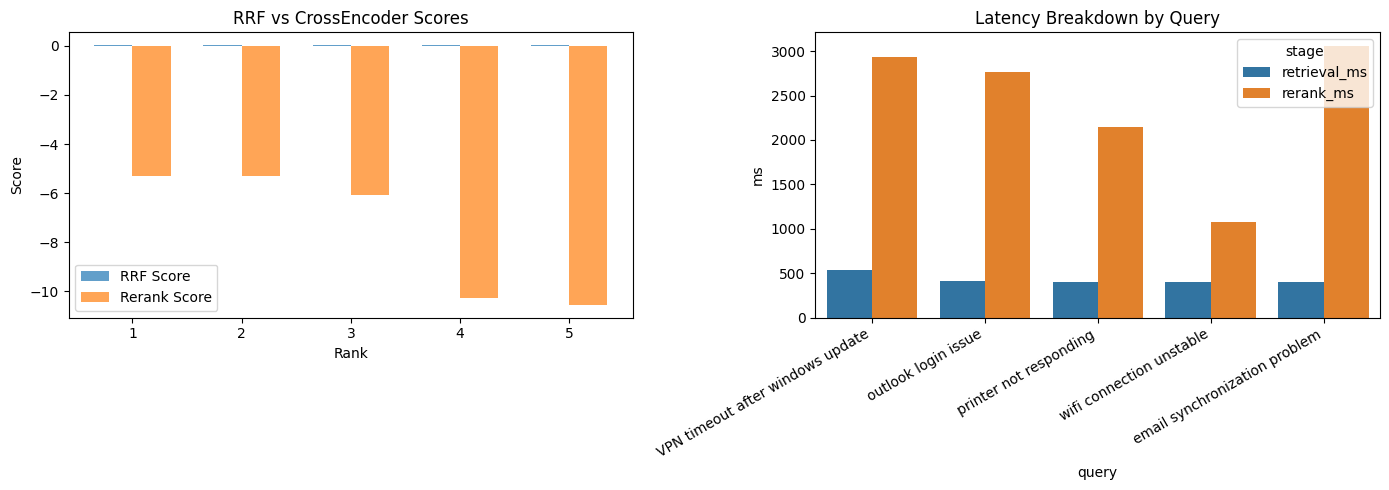

In [ ]:
# ============================================================
# CELL 18 — VISUALIZE RERANK SCORES
# ============================================================

log_step("VISUALIZATION")

if not results.empty and "rerank_score" in results.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # RRF vs Rerank scores comparison
    plot_df = results.head(CONFIG["rerank_top_k"]).copy()
    plot_df["label"] = plot_df["chunk_id"].str.slice(-20)

    ax = axes[0]
    x = np.arange(len(plot_df))
    w = 0.35
    ax.bar(x - w / 2, plot_df["rrf_score"], w, label="RRF Score", alpha=0.7)
    ax.bar(x + w / 2, plot_df["rerank_score"], w, label="Rerank Score", alpha=0.7)
    ax.set_xlabel("Rank")
    ax.set_ylabel("Score")
    ax.set_title("RRF vs CrossEncoder Scores")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["rerank_rank"])
    ax.legend()

    # Latency breakdown
    ax = axes[1]
    if not benchmark_df.empty:
        bp = sns.barplot(data=benchmark_df.melt(
            id_vars=["query"],
            value_vars=["retrieval_ms", "rerank_ms"],
            var_name="stage", value_name="ms"
        ), x="query", y="ms", hue="stage", ax=ax)
        ax.set_title("Latency Breakdown by Query")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    else:
        ax.text(0.5, 0.5, "No benchmark data", ha="center", va="center", transform=ax.transAxes)

    plt.tight_layout()
    plt.show()
else:
    print("No results to visualize.")

In [ ]:
# ============================================================
# CELL 19 — FINAL RERANKING REPORT
# ============================================================

log_step("FINAL RERANKING REPORT")

print(f"Pipeline Components:")
print(f"  FAISS Index:       {index.ntotal:,} vectors (dim={index.d})")
print(f"  BM25 Corpus:       {len(bm25_tokens):,} documents")
print(f"  Metadata:          {len(metadata_df):,} rows")
print(f"  Embedding Model:   {CONFIG['embedding_model_name']}")
print(f"  CrossEncoder:      {CONFIG['cross_encoder_model_name']}")
print(f"  Device:            {embedding_model.device}")

print(f"\nPipeline Parameters:")
print(f"  FAISS Top-K:       {CONFIG['top_k_faiss']}")
print(f"  BM25 Top-K:        {CONFIG['top_k_bm25']}")
print(f"  RRF Constant (k):  {CONFIG['rrf_k']}")
print(f"  Hybrid Top-K:      {CONFIG['hybrid_top_k']}")
print(f"  Rerank Top-K:      {CONFIG['rerank_top_k']}")

print(f"\nBenchmark Results:")
if not benchmark_df.empty:
    print(f"  Avg Retrieval:     {benchmark_df['retrieval_ms'].mean():.1f}ms")
    print(f"  Avg Rerank:        {benchmark_df['rerank_ms'].mean():.1f}ms")
    print(f"  Avg Total:         {benchmark_df['total_ms'].mean():.1f}ms")

print(f"\nExports:")
print(f"  Results:           {CONFIG['export_path']}")
print(f"  Benchmarks:        {CONFIG['benchmark_export_path']}")

print(f"\n{'=' * 60}")
print(f"  RERANKING PIPELINE EXECUTION COMPLETE")
print(f"  Pipeline is ready for notebook 09 (RAG Generation)")
print(f"{'=' * 60}")


  FINAL RERANKING REPORT
Pipeline Components:
  FAISS Index:       228,561 vectors (dim=384)
  BM25 Corpus:       228,561 documents
  Metadata:          228,561 rows
  Embedding Model:   BAAI/bge-small-en-v1.5
  CrossEncoder:      cross-encoder/ms-marco-MiniLM-L-12-v2
  Device:            cpu

Pipeline Parameters:
  FAISS Top-K:       20
  BM25 Top-K:        20
  RRF Constant (k):  60
  Hybrid Top-K:      20
  Rerank Top-K:      5

Benchmark Results:
  Avg Retrieval:     430.9ms
  Avg Rerank:        2395.6ms
  Avg Total:         2826.5ms

Exports:
  Results:           ../evaluation/reranking_results.csv
  Benchmarks:        ../evaluation/benchmarks/reranking_latency.csv

  RERANKING PIPELINE EXECUTION COMPLETE
  Pipeline is ready for notebook 09 (RAG Generation)
